<a href="https://colab.research.google.com/github/jaycss9/car-market-trends-analysis/blob/main/CAR_MARKET_TRENDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
import pandas as pd

CSV_URL = (
    "https://raw.githubusercontent.com/"
    "jaycss9/car-market-trends-analysis/"
    "main/car_dekho.csv"
)

df = pd.read_csv(CSV_URL)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully
Dataset shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [9]:
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
df.shape

(301, 9)

In [10]:
df.columns.to_list()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Kms_Driven',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [12]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [13]:
import io

In [14]:
# Remove accidental spaces from column names
df.columns = df.columns.str.strip()

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of exact duplicate rows:")
print(df.duplicated().sum())

Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Data types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Number of exact duplicate rows:
2


In [15]:
numeric_columns = [
    "Year",
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Owner"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print(df[numeric_columns].dtypes)

Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Owner              int64
dtype: object


In [16]:
# Value-retention formula:
# Selling price divided by present price, multiplied by 100

df["Retention_Pct"] = (
    df["Selling_Price"] / df["Present_Price"]
) * 100

# The latest model year in this dataset is 2018
REFERENCE_YEAR = int(df["Year"].max())

# Vehicle-age formula
df["Vehicle_Age"] = REFERENCE_YEAR - df["Year"]

# Create the same age groups used in the PPT
df["Age_Cohort"] = pd.cut(
    df["Vehicle_Age"],
    bins=[-1, 2, 5, 8, np.inf],
    labels=[
        "0–2 years",
        "3–5 years",
        "6–8 years",
        "9+ years"
    ]
)

df[
    [
        "Car_Name",
        "Year",
        "Selling_Price",
        "Present_Price",
        "Retention_Pct",
        "Vehicle_Age",
        "Age_Cohort"
    ]
].head()

,Car_Name,Year,Selling_Price,Present_Price,Retention_Pct,Vehicle_Age,Age_Cohort
0,ritz,2014,3.35,5.59,59.928444,4,3–5 years
1,sx4,2013,4.75,9.54,49.790356,5,3–5 years
2,ciaz,2017,7.25,9.85,73.604061,1,0–2 years
3,wagon r,2011,2.85,4.15,68.674699,7,6–8 years
4,swift,2014,4.60,6.87,66.957787,4,3–5 years


In [17]:

total_records = len(df)
unique_models = df["Car_Name"].nunique()

average_selling_price = df["Selling_Price"].mean()
median_selling_price = df["Selling_Price"].median()

average_present_price = df["Present_Price"].mean()

median_retention = df["Retention_Pct"].median()
average_retention = df["Retention_Pct"].mean()

price_correlation = df["Selling_Price"].corr(
    df["Present_Price"]
)

print("CAR MARKET SUMMARY")
print("-" * 45)

print(f"Total records: {total_records}")
print(f"Unique models: {unique_models}")
print(f"Model-year range: {df['Year'].min()}–{df['Year'].max()}")

print(f"\nAverage selling price: ₹{average_selling_price:.2f} lakh")
print(f"Median selling price: ₹{median_selling_price:.2f} lakh")
print(f"Average present price: ₹{average_present_price:.2f} lakh")

print(f"\nMedian value retention: {median_retention:.1f}%")
print(f"Average value retention: {average_retention:.1f}%")

print(
    f"Present-price correlation: "
    f"{price_correlation:.3f}"
)

CAR MARKET SUMMARY
---------------------------------------------
Total records: 301
Unique models: 98
Model-year range: 2003–2018

Average selling price: ₹4.66 lakh
Median selling price: ₹3.60 lakh
Average present price: ₹7.63 lakh

Median value retention: 65.5%
Average value retention: 63.4%
Present-price correlation: 0.879


In [18]:
fuel_summary = (
    df.groupby("Fuel_Type", as_index=False)
      .agg(
          Listings=("Car_Name", "size"),
          Average_Selling_Price=("Selling_Price", "mean"),
          Median_Selling_Price=("Selling_Price", "median"),
          Average_Retention=("Retention_Pct", "mean")
      )
)

fuel_summary.round(2)

,Fuel_Type,Listings,Average_Selling_Price,Median_Selling_Price,Average_Retention
0,CNG,2,3.10,3.10,50.98
1,Diesel,60,10.28,7.75,67.96
2,Petrol,239,3.26,2.65,62.41


In [19]:
transmission_summary = (
    df.groupby("Transmission", as_index=False)
      .agg(
          Listings=("Car_Name", "size"),
          Average_Selling_Price=("Selling_Price", "mean"),
          Median_Selling_Price=("Selling_Price", "median"),
          Average_Retention=("Retention_Pct", "mean")
      )
)

transmission_summary.round(2)

,Transmission,Listings,Average_Selling_Price,Median_Selling_Price,Average_Retention
0,Automatic,40,9.42,5.80,63.93
1,Manual,261,3.93,3.25,63.37


In [20]:
model_summary = (
    df.groupby("Car_Name", as_index=False)
      .agg(
          Listings=("Car_Name", "size"),
          Average_Selling_Price=("Selling_Price", "mean"),
          Average_Present_Price=("Present_Price", "mean"),
          Average_Retention=("Retention_Pct", "mean")
      )
)

top_models = (
    model_summary[
        model_summary["Listings"] >= 2
    ]
    .nlargest(5, "Average_Selling_Price")
)


In [21]:
model_summary = (
    df.groupby("Car_Name", as_index=False)
      .agg(
          Listings=("Car_Name", "size"),
          Average_Selling_Price=("Selling_Price", "mean"),
          Average_Present_Price=("Present_Price", "mean"),
          Average_Retention=("Retention_Pct", "mean")
      )
)

top_models = (
    model_summary[
        model_summary["Listings"] >= 2
    ]
    .nlargest(5, "Average_Selling_Price")
)

top_models.round(2)

,Car_Name,Listings,Average_Selling_Price,Average_Present_Price,Average_Retention
81,fortuner,11,18.69,30.73,59.56
86,innova,9,12.78,17.85,65.55
72,creta,3,11.80,13.60,86.76
74,elantra,2,11.60,14.79,78.43
68,ciaz,9,7.47,9.76,77.51


In [22]:
age_summary = (
    df.groupby(
        "Age_Cohort",
        observed=True,
        as_index=False
    )
    .agg(
        Listings=("Car_Name", "size"),
        Average_Retention=("Retention_Pct", "mean"),
        Median_Retention=("Retention_Pct", "median"),
        Average_Selling_Price=("Selling_Price", "mean"),
        Median_Kms_Driven=("Kms_Driven", "median")
    )
)

age_summary.round(2)

,Age_Cohort,Listings,Average_Retention,Median_Retention,Average_Selling_Price,Median_Kms_Driven
0,0–2 years,86,82.62,82.74,5.67,12000.0
1,3–5 years,132,65.32,65.33,5.00,35933.0
2,6–8 years,57,47.07,47.86,3.73,45000.0
3,9+ years,26,26.42,26.67,1.69,67281.0


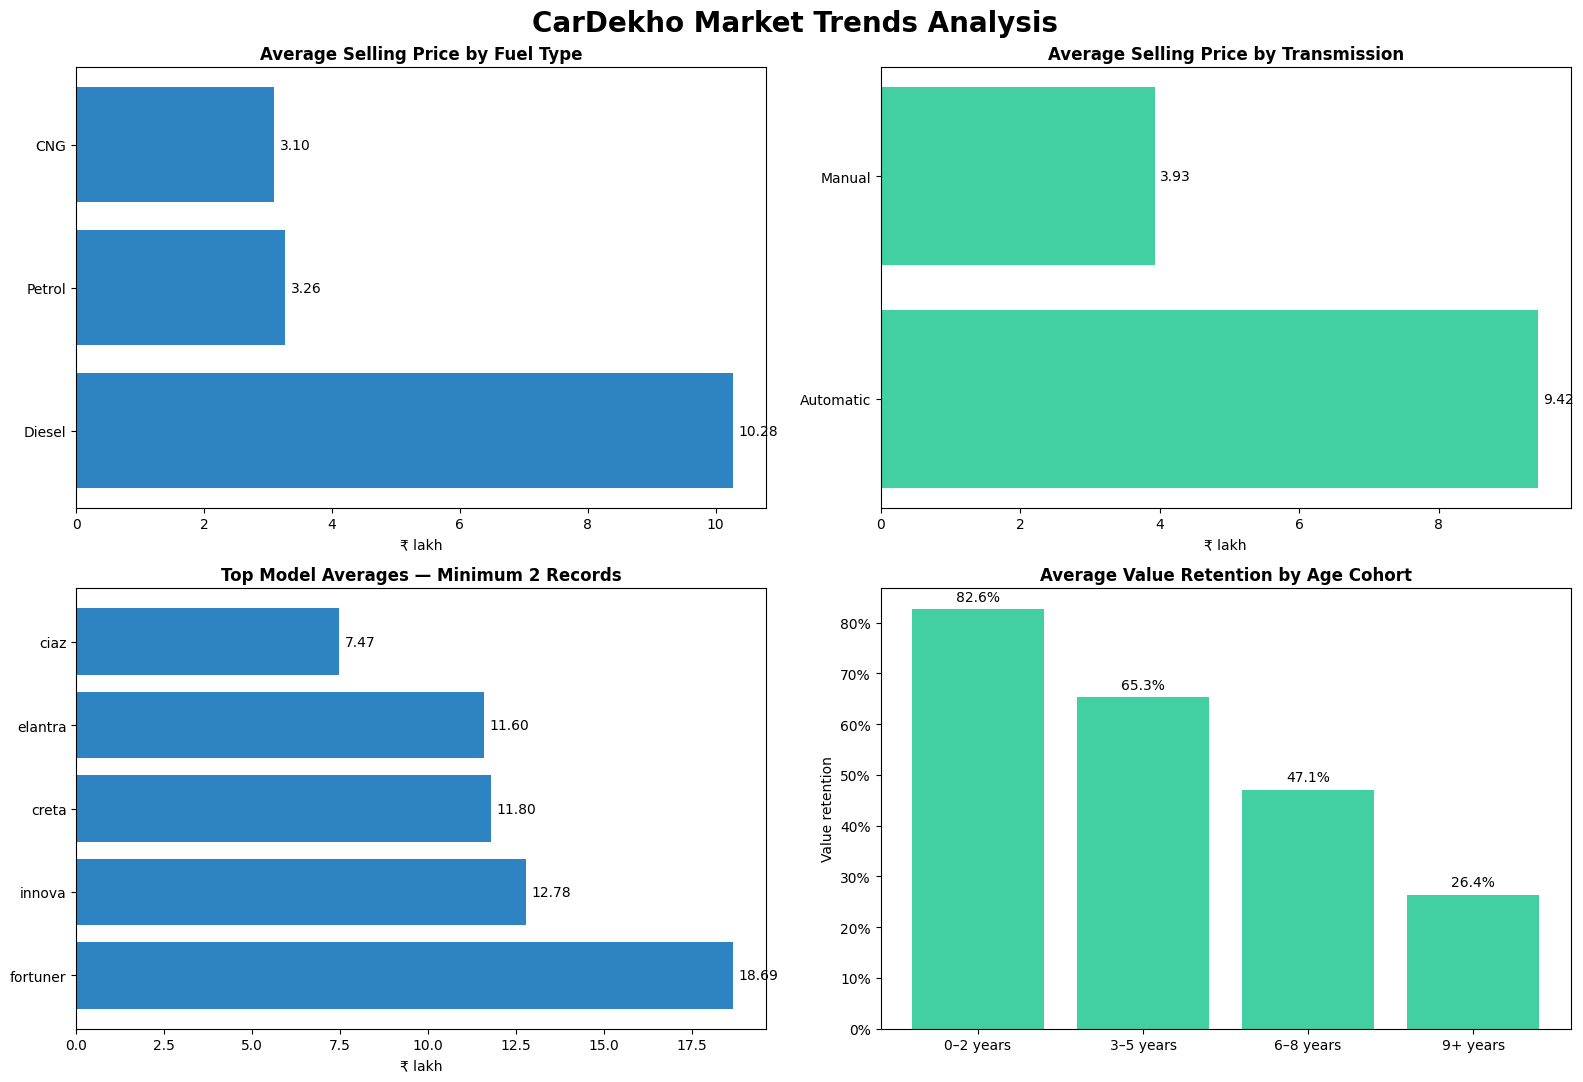

In [24]:
blue = "#2E83C3"
green = "#42D0A2"
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11)
)

# -----------------------------
# Chart 1: Fuel-type prices
# -----------------------------

fuel_order = ["Diesel", "Petrol", "CNG"]

fuel_chart = (
    fuel_summary
    .set_index("Fuel_Type")
    .loc[fuel_order]
)

bars = axes[0, 0].barh(
    fuel_order,
    fuel_chart["Average_Selling_Price"],
    color=blue
)

axes[0, 0].bar_label(
    bars,
    fmt="%.2f",
    padding=4
)

axes[0, 0].set_title(
    "Average Selling Price by Fuel Type",
    fontweight="bold"
)

axes[0, 0].set_xlabel("₹ lakh")
axes[0, 0].set_ylabel("")

# -----------------------------
# Chart 2: Transmission prices
# -----------------------------

transmission_order = [
    "Automatic",
    "Manual"
]

transmission_chart = (
    transmission_summary
    .set_index("Transmission")
    .loc[transmission_order]
)

bars = axes[0, 1].barh(
    transmission_order,
    transmission_chart["Average_Selling_Price"],
    color=green
)

axes[0, 1].bar_label(
    bars,
    fmt="%.2f",
    padding=4
)

axes[0, 1].set_title(
    "Average Selling Price by Transmission",
    fontweight="bold"
)

axes[0, 1].set_xlabel("₹ lakh")
axes[0, 1].set_ylabel("")

# -----------------------------
# Chart 3: Top models
# -----------------------------

bars = axes[1, 0].barh(
    top_models["Car_Name"],
    top_models["Average_Selling_Price"],
    color=blue
)

axes[1, 0].bar_label(
    bars,
    fmt="%.2f",
    padding=4
)

axes[1, 0].set_title(
    "Top Model Averages — Minimum 2 Records",
    fontweight="bold"
)

axes[1, 0].set_xlabel("₹ lakh")
axes[1, 0].set_ylabel("")

# -----------------------------
# Chart 4: Retention by age
# -----------------------------

bars = axes[1, 1].bar(
    age_summary["Age_Cohort"].astype(str),
    age_summary["Average_Retention"],
    color=green
)

axes[1, 1].bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in age_summary["Average_Retention"]
    ],
    padding=4
)

axes[1, 1].set_title(
    "Average Value Retention by Age Cohort",
    fontweight="bold"
)

axes[1, 1].set_ylabel("Value retention")
axes[1, 1].yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

plt.suptitle(
    "CarDekho Market Trends Analysis",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "CarDekho_PPT_Results.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()